# 🔍 Análisis Exploratorio de Datos — Delitos en Colombia
---
**Fuente:** Policía Nacional de Colombia — Base de datos de delitos  
**Archivo:** `v_delitos.csv` (~2.38 millones de registros)  
**Período:** 2020 – 2025  

Este proyecto sigue una estructura secuencial:  
cada paso construye sobre el anterior, con explicaciones, código reproducible y conclusiones intermedias.

| Paso | Tema |
|------|------|
| 0 | Configuración del entorno |
| 1 | Carga e inspección inicial |
| 2 | Calidad de datos y valores faltantes |
| 3 | Análisis univariado |
| 4 | Análisis temporal |
| 5 | Análisis geográfico |
| 6 | Análisis por víctima (género y edad) |
| 7 | Análisis de armas |
| 8 | Correlaciones y patrones cruzados |
| 9 | Conclusiones y hallazgos clave |

## Paso 0 — Configuración del entorno

Importamos todas las librerías que usaremos a lo largo del proyecto. Esto centraliza las dependencias y facilita la reproducibilidad.

## 📥 Paso 1 — Carga e inspección inicial

### ¿Qué haremos?
- Cargar el CSV desde el archivo comprimido
- Revisar dimensiones, tipos de datos y primeras filas
- Entender el significado de cada columna

### Diccionario de datos

| Columna | Descripción |
|---------|-------------|
| `tipo` | Categoría macro del delito |
| `delito` | Artículo del Código Penal infringido |
| `tipo_arma` | Medio o arma utilizada |
| `departamento` | Departamento de Colombia |
| `municipio` | Municipio donde ocurrió el hecho |
| `cod_dane` | Código DANE del municipio |
| `genero` | Género de la víctima |
| `rango_edad` | Rango etario de la víctima |
| `fecha` | Fecha del delito (YYYY-MM-DD) |
| `cantidad` | Número de casos registrados |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!find /content/drive -name "v_delitos.csv"

/content/drive/MyDrive/Proyectos_data/datasets/v_delitos.csv


In [ ]:
import subprocess
result = subprocess.run(['find', '/content/drive', '-name', 'v_delitos.csv'],
                       capture_output=True, text=True)
print(result.stdout)

/content/drive/MyDrive/Proyectos_data/datasets/v_delitos.csv



In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})
sns.set_palette('tab10')

print('✅ Entorno configurado correctamente.')

✅ Entorno configurado correctamente.


In [ ]:
import subprocess
result = subprocess.run(['find', '/content/drive', '-name', 'v_delitos.csv'],
                       capture_output=True, text=True)
print(result.stdout if result.stdout else "❌ No encontrado")

/content/drive/MyDrive/Proyectos_data/datasets/v_delitos.csv



In [ ]:
ARCHIVO = '/content/drive/MyDrive/Proyectos_data/datasets/v_delitos.csv'

print('⏳ Cargando datos... puede tardar 1-2 minutos (archivo de ~360 MB)')

df = pd.read_csv(
    ARCHIVO,
    parse_dates=['fecha'],
    dtype={
        'tipo'         : 'category',
        'delito'       : 'category',
        'tipo_arma'    : 'category',
        'departamento' : 'category',
        'municipio'    : 'category',
        'genero'       : 'category',
        'rango_edad'   : 'category',
        'cod_dane'     : str,
    },
    low_memory=False
)

print(f'✅ Cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

⏳ Cargando datos... puede tardar 1-2 minutos (archivo de ~360 MB)
✅ Cargado: 2,382,453 filas × 10 columnas


In [ ]:
display(df.head(10))

,tipo,delito,tipo_arma,departamento,municipio,cod_dane,genero,rango_edad,fecha,cantidad
0,Homicidios intencionales,ARTÍCULO 103. HOMICIDIO,ARMA BLANCA / CORTOPUNZANTE,ANTIOQUIA,Medellín (CT),05001,FEMENINO,ADOLESCENTES,2020-12-15,1
1,Homicidios intencionales,ARTÍCULO 103. HOMICIDIO,ARMA BLANCA / CORTOPUNZANTE,ANTIOQUIA,Medellín (CT),05001,FEMENINO,ADOLESCENTES,2025-05-10,1
2,Homicidios intencionales,ARTÍCULO 103. HOMICIDIO,ARMA BLANCA / CORTOPUNZANTE,ANTIOQUIA,Medellín (CT),05001,FEMENINO,ADULTOS,2020-01-10,1
3,Homicidios intencionales,ARTÍCULO 103. HOMICIDIO,ARMA BLANCA / CORTOPUNZANTE,ANTIOQUIA,Medellín (CT),05001,FEMENINO,ADULTOS,2020-02-26,1
4,Homicidios intencionales,ARTÍCULO 103. HOMICIDIO,ARMA BLANCA / CORTOPUNZANTE,ANTIOQUIA,Medellín (CT),05001,FEMENINO,ADULTOS,2020-05-31,1
5,Homicidios intencionales,ARTÍCULO 103. HOMICIDIO,ARMA BLANCA / CORTOPUNZANTE,ANTIOQUIA,Medellín (CT),05001,FEMENINO,ADULTOS,2020-06-02,1
6,Homicidios intencionales,ARTÍCULO 103. HOMICIDIO,ARMA BLANCA / CORTOPUNZANTE,ANTIOQUIA,Medellín (CT),05001,FEMENINO,ADULTOS,2020-07-16,1
7,Homicidios intencionales,ARTÍCULO 103. HOMICIDIO,ARMA BLANCA / CORTOPUNZANTE,ANTIOQUIA,Medellín (CT),05001,FEMENINO,ADULTOS,2020-08-27,1
8,Homicidios intencionales,ARTÍCULO 103. HOMICIDIO,ARMA BLANCA / CORTOPUNZANTE,ANTIOQUIA,Medellín (CT),05001,FEMENINO,ADULTOS,2020-09-01,1
9,Homicidios intencionales,ARTÍCULO 103. HOMICIDIO,ARMA BLANCA / CORTOPUNZANTE,ANTIOQUIA,Medellín (CT),05001,FEMENINO,ADULTOS,2020-09-03,1


In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2382453 entries, 0 to 2382452
Data columns (total 10 columns):
 #   Column        Dtype         
---  ------        -----         
 0   tipo          category      
 1   delito        category      
 2   tipo_arma     category      
 3   departamento  category      
 4   municipio     category      
 5   cod_dane      object        
 6   genero        category      
 7   rango_edad    category      
 8   fecha         datetime64[ns]
 9   cantidad      int64         
dtypes: category(7), datetime64[ns](1), int64(1), object(1)
memory usage: 177.3 MB


In [ ]:
display(df['cantidad'].describe().to_frame().T.round(2))

,count,mean,std,min,25%,50%,75%,max
cantidad,2382453.0,2.08,6.17,1.0,1.0,1.0,2.0,302.0


### Valores nulos:

In [ ]:
nulos = df.isnull().sum().rename('nulos')
pct   = (nulos / len(df) * 100).rename('% del total').round(2)
display(pd.concat([nulos, pct], axis=1))

,nulos,% del total
tipo,0,0.0
delito,0,0.0
tipo_arma,0,0.0
departamento,0,0.0
municipio,1,0.0
cod_dane,0,0.0
genero,0,0.0
rango_edad,0,0.0
fecha,0,0.0
cantidad,0,0.0


### Duplicados:

In [ ]:
n_dup = df.duplicated().sum()
print(f'🔁 Filas duplicadas exactas: {n_dup:,} ({n_dup/len(df)*100:.2f}%)')

🔁 Filas duplicadas exactas: 0 (0.00%)


### Rango de fechas:

In [ ]:
print(f'📅 Fecha mínima : {df["fecha"].min().date()}')
print(f'📅 Fecha máxima : {df["fecha"].max().date()}')

fechas_raras = df[(df['fecha'] < '2010-01-01') | (df['fecha'] > pd.Timestamp.today())]
print(f'⚠️  Registros con fechas fuera de rango: {len(fechas_raras):,}')

📅 Fecha mínima : 2020-01-01
📅 Fecha máxima : 2026-12-02
⚠️  Registros con fechas fuera de rango: 13,025


### Inspeccionar las fechas fuera de rango:

In [ ]:
print("Distribución de fechas futuras por año:")
display(
    fechas_raras.groupby(df['fecha'].dt.year)['cantidad']
    .sum()
    .rename('casos')
    .to_frame()
)

Distribución de fechas futuras por año:


,casos
fecha,
2026,29858


### Limpieza y columnas de tiempo derivadas:

In [ ]:
# Excluir fechas futuras (después de hoy)
hoy = pd.Timestamp.today()
df = df[df['fecha'] <= hoy].copy()
print(f'✅ Registros tras excluir fechas futuras: {len(df):,}')

# Columnas derivadas de tiempo
df['anio']      = df['fecha'].dt.year
df['mes']       = df['fecha'].dt.month
df['trimestre'] = df['fecha'].dt.quarter
df['dia_sem']   = df['fecha'].dt.day_name()

print('\n✅ Columnas de tiempo creadas: anio, mes, trimestre, dia_sem')
display(df[['fecha', 'anio', 'mes', 'trimestre', 'dia_sem']].head(5))

✅ Registros tras excluir fechas futuras: 2,369,428

✅ Columnas de tiempo creadas: anio, mes, trimestre, dia_sem


,fecha,anio,mes,trimestre,dia_sem
0,2020-12-15,2020,12,4,Tuesday
1,2025-05-10,2025,5,2,Saturday
2,2020-01-10,2020,1,1,Friday
3,2020-02-26,2020,2,1,Wednesday
4,2020-05-31,2020,5,2,Sunday


### Paso 3 — Análisis univariado.

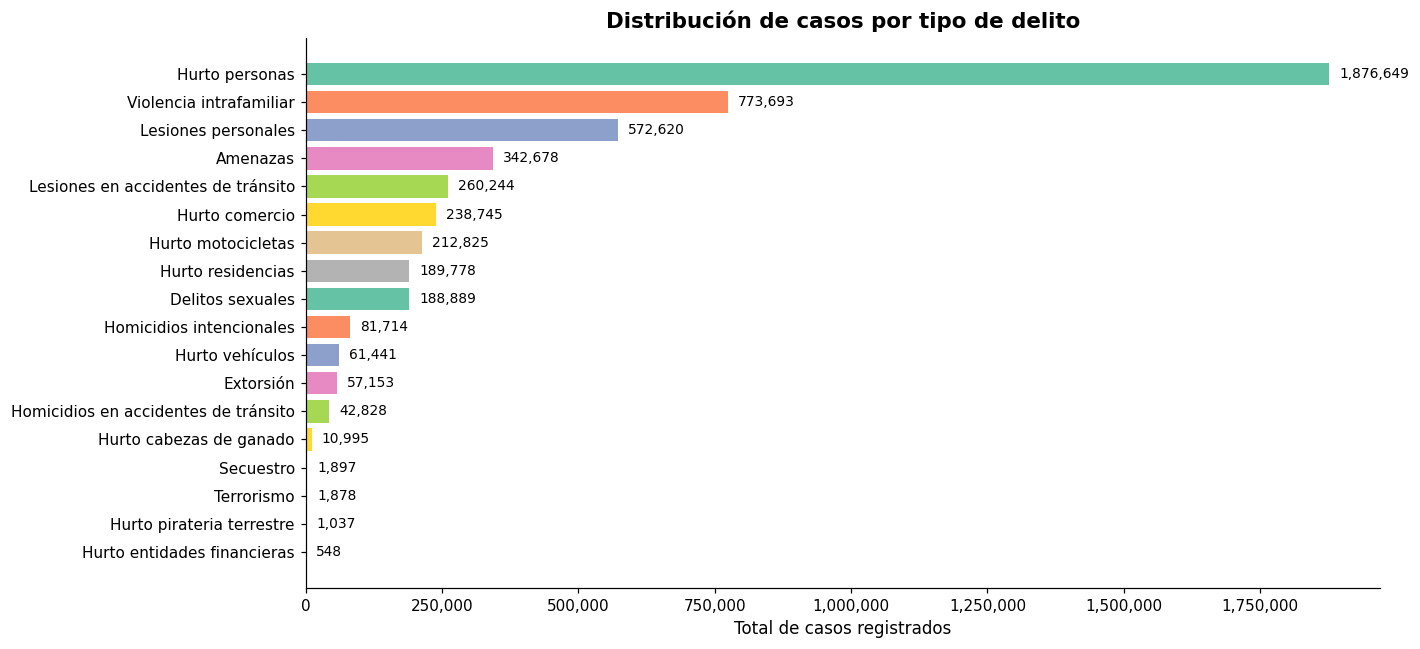

,Tipo de delito,Total casos,% del total
0,Hurto personas,1876649,38.18
1,Violencia intrafamiliar,773693,15.74
2,Lesiones personales,572620,11.65
3,Amenazas,342678,6.97
4,Lesiones en accidentes de tránsito,260244,5.29
5,Hurto comercio,238745,4.86
6,Hurto motocicletas,212825,4.33
7,Hurto residencias,189778,3.86
8,Delitos sexuales,188889,3.84
9,Homicidios intencionales,81714,1.66


In [ ]:
PALETTE_DELITOS = sns.color_palette('Set2', 18)

tipo_counts = (df.groupby('tipo', observed=True)['cantidad']
               .sum()
               .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(tipo_counts.index, tipo_counts.values, color=PALETTE_DELITOS)
ax.set_xlabel('Total de casos registrados')
ax.set_title('Distribución de casos por tipo de delito', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()

for bar, val in zip(bars, tipo_counts.values):
    ax.text(val + tipo_counts.max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Tabla resumen
resumen_tipo = tipo_counts.reset_index()
resumen_tipo.columns = ['Tipo de delito', 'Total casos']
resumen_tipo['% del total'] = (resumen_tipo['Total casos'] /
                                resumen_tipo['Total casos'].sum() * 100).round(2)
display(resumen_tipo)

### Top 15 artículos del Código Penal:

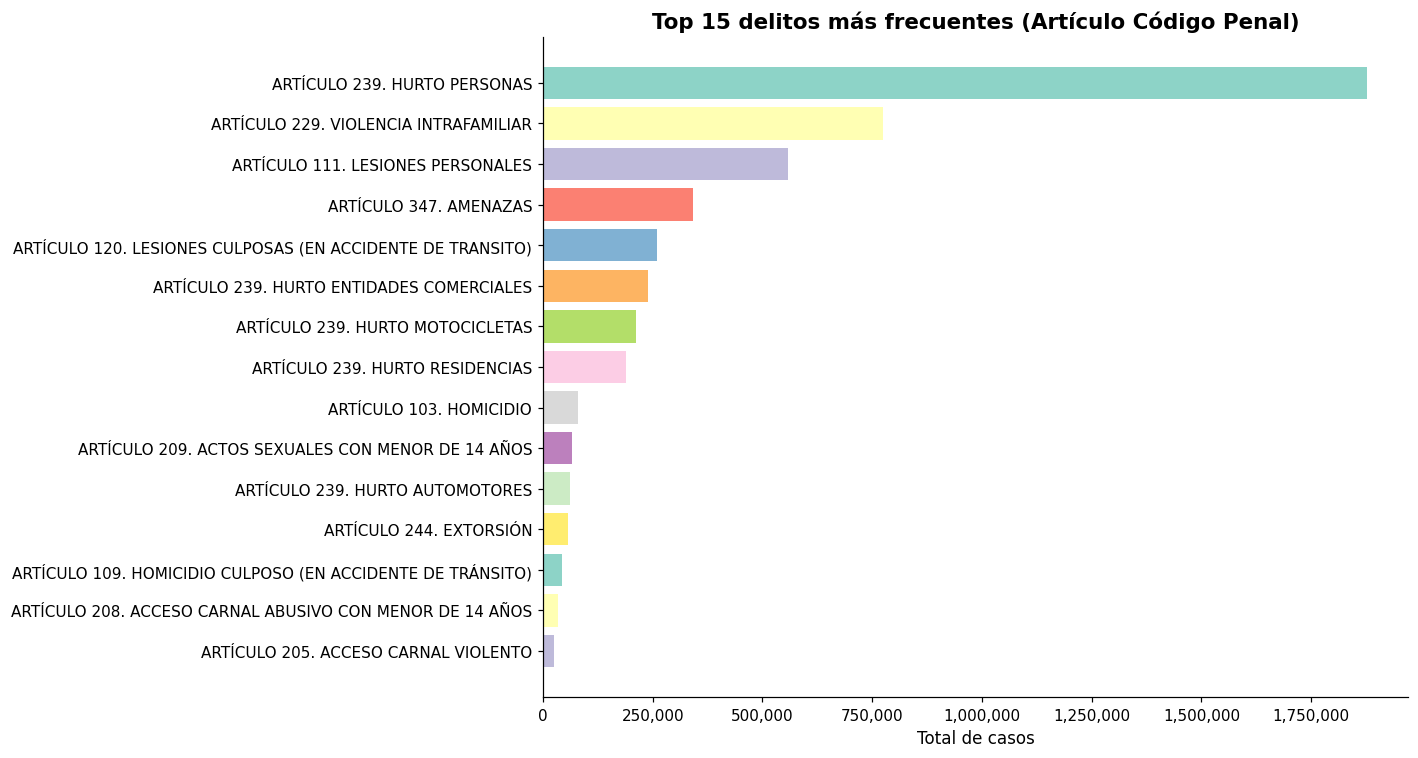

In [ ]:
top_delitos = (df.groupby('delito', observed=True)['cantidad']
               .sum()
               .sort_values(ascending=False)
               .head(15))

fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(
    [d[:65] for d in top_delitos.index],
    top_delitos.values,
    color=sns.color_palette('Set3', 15)
)
ax.set_xlabel('Total de casos')
ax.set_title('Top 15 delitos más frecuentes (Artículo Código Penal)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Paso 4 — Análisis temporal

In [ ]:
# 2026 está incompleto (solo enero-mayo) → lo excluimos de gráficas anuales
df_hist = df[df['anio'] < 2026].copy()
print(f'✅ df_hist: {len(df_hist):,} registros (2020–2025, años completos)')
print(df_hist.groupby('anio')['cantidad'].sum())

✅ df_hist: 2,327,644 registros (2020–2025, años completos)
anio
2020    655220
2021    764354
2022    866659
2023    919963
2024    834143
2025    780225
Name: cantidad, dtype: int64


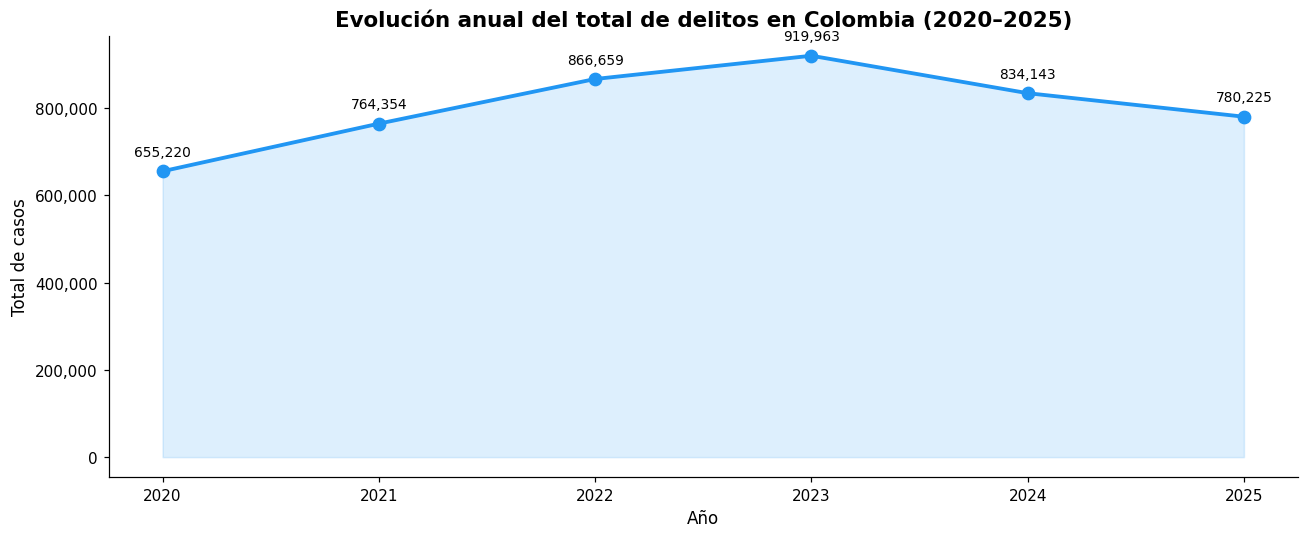

In [ ]:
anual = df_hist.groupby('anio')['cantidad'].sum()

fig, ax = plt.subplots()
ax.plot(anual.index, anual.values, marker='o', linewidth=2.5,
        markersize=8, color='#2196F3')
ax.fill_between(anual.index, anual.values, alpha=0.15, color='#2196F3')
ax.set_title('Evolución anual del total de delitos en Colombia (2020–2025)',
             fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Total de casos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xticks(anual.index)
for x, y in zip(anual.index, anual.values):
    ax.annotate(f'{y:,.0f}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Estacionalidad mensual:

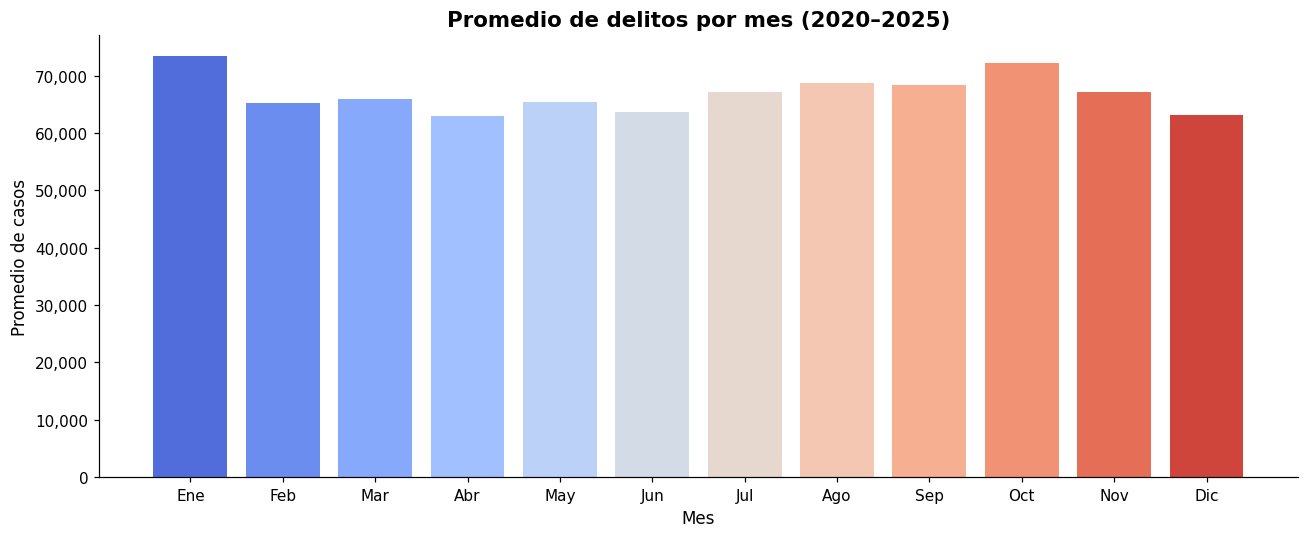

In [ ]:
meses_nombre = ['Ene','Feb','Mar','Abr','May','Jun',
                 'Jul','Ago','Sep','Oct','Nov','Dic']

mensual = df_hist.groupby(['anio', 'mes'])['cantidad'].sum().reset_index()
prom_mes = mensual.groupby('mes')['cantidad'].mean()

fig, ax = plt.subplots()
ax.bar(prom_mes.index, prom_mes.values, color=sns.color_palette('coolwarm', 12))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nombre)
ax.set_title('Promedio de delitos por mes (2020–2025)', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Promedio de casos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

📈 Enero y Octubre son los meses pico — enero probablemente por festividades de fin de año previas, octubre sin una causa obvia aún
📉 Abril, Junio y Diciembre son los meses más bajos — curioso que diciembre sea bajo (posiblemente subregistro)
La variación es relativamente pequeña (~63K–73K), no hay un mes dramáticamente peor

### Heatmap año × mes:

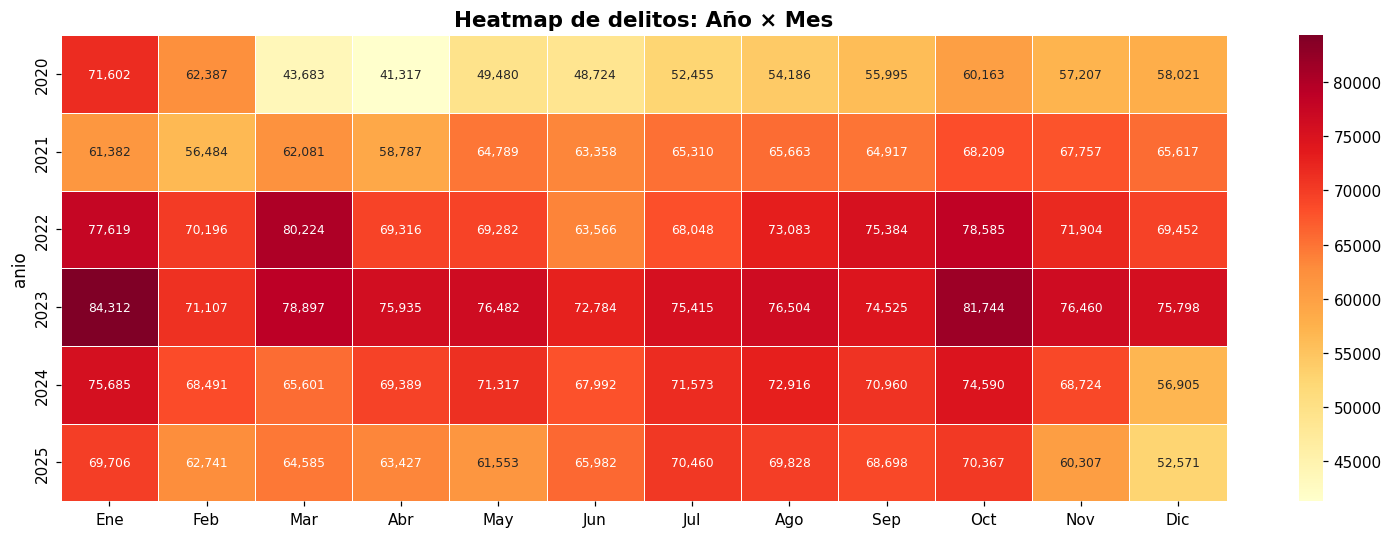

In [ ]:
pivot_tiempo = (df_hist.groupby(['anio', 'mes'])['cantidad']
                .sum()
                .unstack(fill_value=0))
pivot_tiempo.columns = meses_nombre

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_tiempo, annot=True, fmt=',d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Heatmap de delitos: Año × Mes', fontweight='bold')
plt.tight_layout()
plt.show()

Heatmap año × mes:

🔴 Enero 2023 (84,312) es el mes-año con más delitos de todo el período
🟡 Abril 2020 (41,317) es el mínimo absoluto — cuarentena estricta COVID
2020 tiene un patrón claramente diferente al resto: caída profunda en Mar-Jun, luego recuperación

### Por día de la semana:

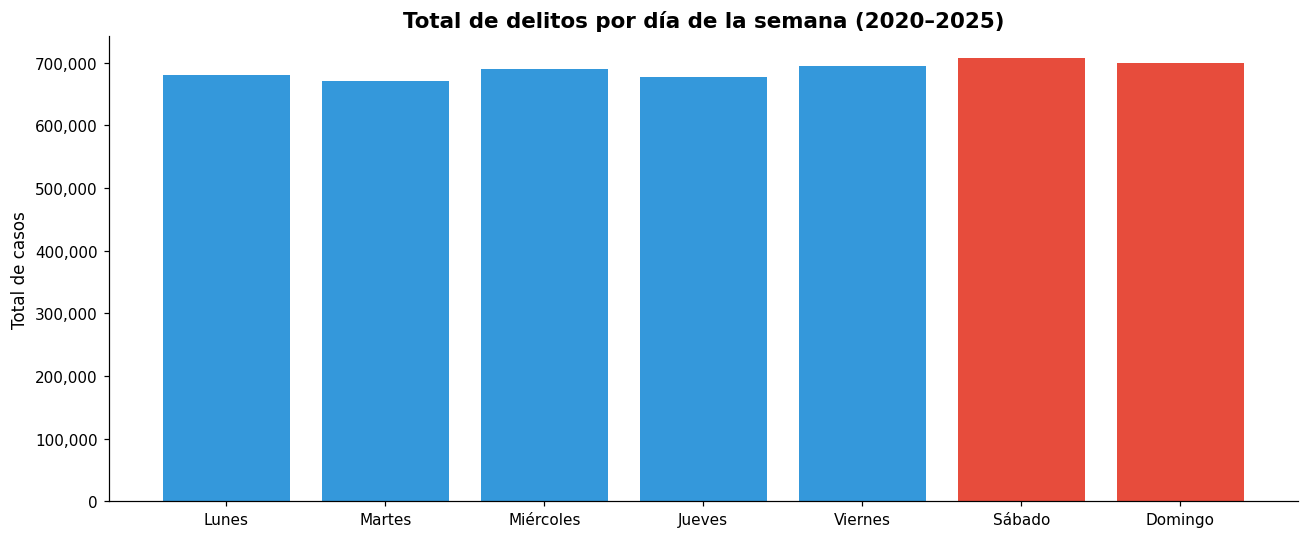

In [ ]:
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dias_es    = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

dia_counts = (df_hist.groupby('dia_sem')['cantidad']
              .sum()
              .reindex(orden_dias))
dia_counts.index = dias_es

fig, ax = plt.subplots()
ax.bar(dia_counts.index, dia_counts.values,
       color=['#e74c3c' if d in ['Sábado','Domingo'] else '#3498db'
              for d in dias_es])
ax.set_title('Total de delitos por día de la semana (2020–2025)', fontweight='bold')
ax.set_ylabel('Total de casos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

La distribución es sorprendentemente uniforme (~670K–710K por día)
Sábado es marginalmente el más alto — consistente con más actividad nocturna y de espacio público
No hay un día dramáticamente peor, lo que sugiere que los delitos registrados no dependen mucho del día

### Paso 5 — Análisis geográfico:

Top 15 departamentos:

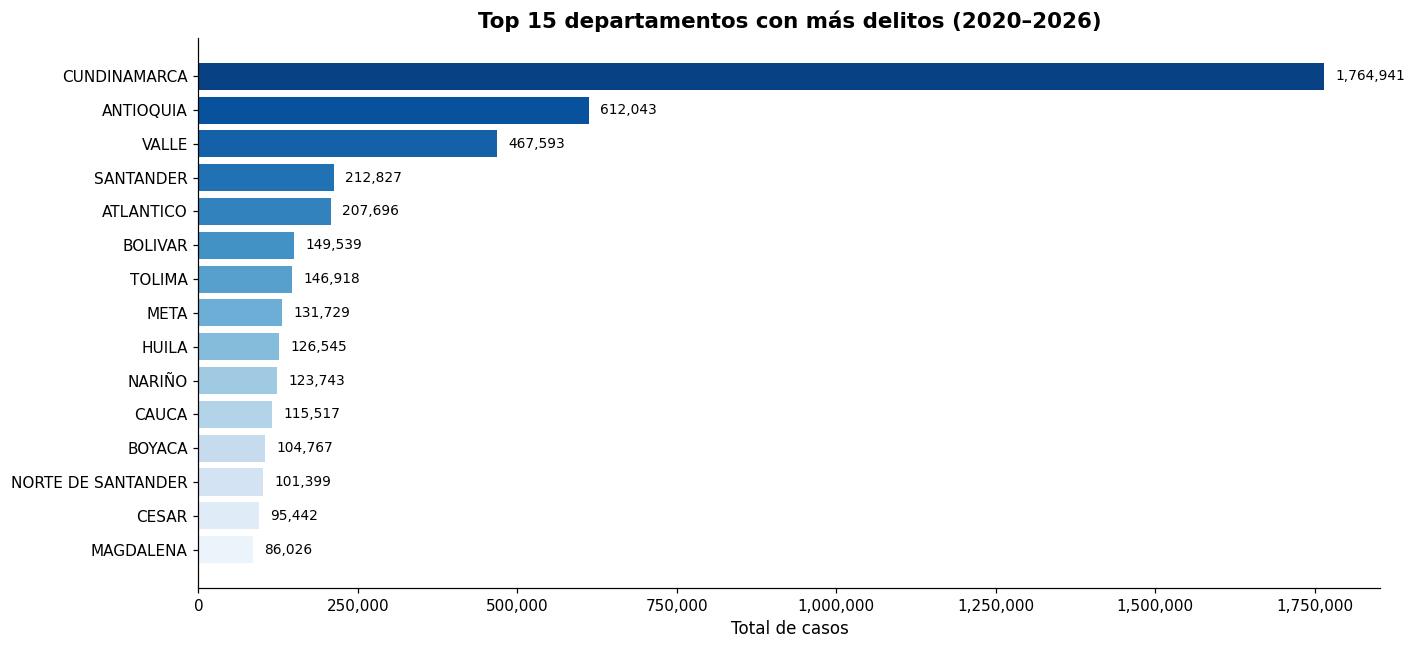

In [ ]:
PALETTE_GEO = sns.color_palette('Blues_r', 15)

top_deptos = (df.groupby('departamento', observed=True)['cantidad']
              .sum()
              .sort_values(ascending=False)
              .head(15))

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top_deptos.index, top_deptos.values, color=PALETTE_GEO)
ax.set_xlabel('Total de casos')
ax.set_title('Top 15 departamentos con más delitos (2020–2026)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()

for bar, val in zip(bars, top_deptos.values):
    ax.text(val + top_deptos.max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Top 20 municipios:


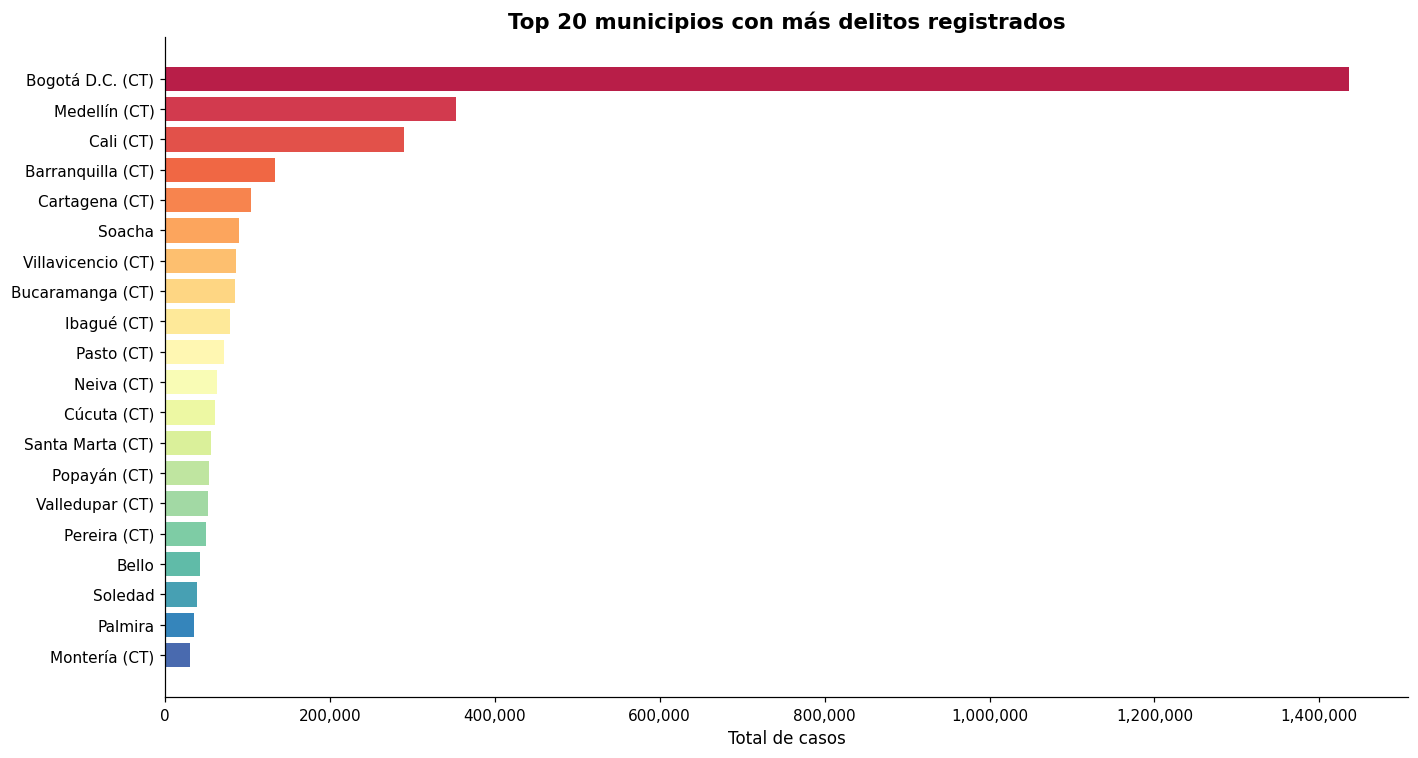

In [ ]:
top_muni = (df.groupby('municipio', observed=True)['cantidad']
            .sum()
            .sort_values(ascending=False)
            .head(20))

fig, ax = plt.subplots(figsize=(13, 7))
ax.barh([m[:45] for m in top_muni.index], top_muni.values,
        color=sns.color_palette('Spectral', 20))
ax.set_xlabel('Total de casos')
ax.set_title('Top 20 municipios con más delitos registrados', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

###  Heatmap departamento × tipo de delito:

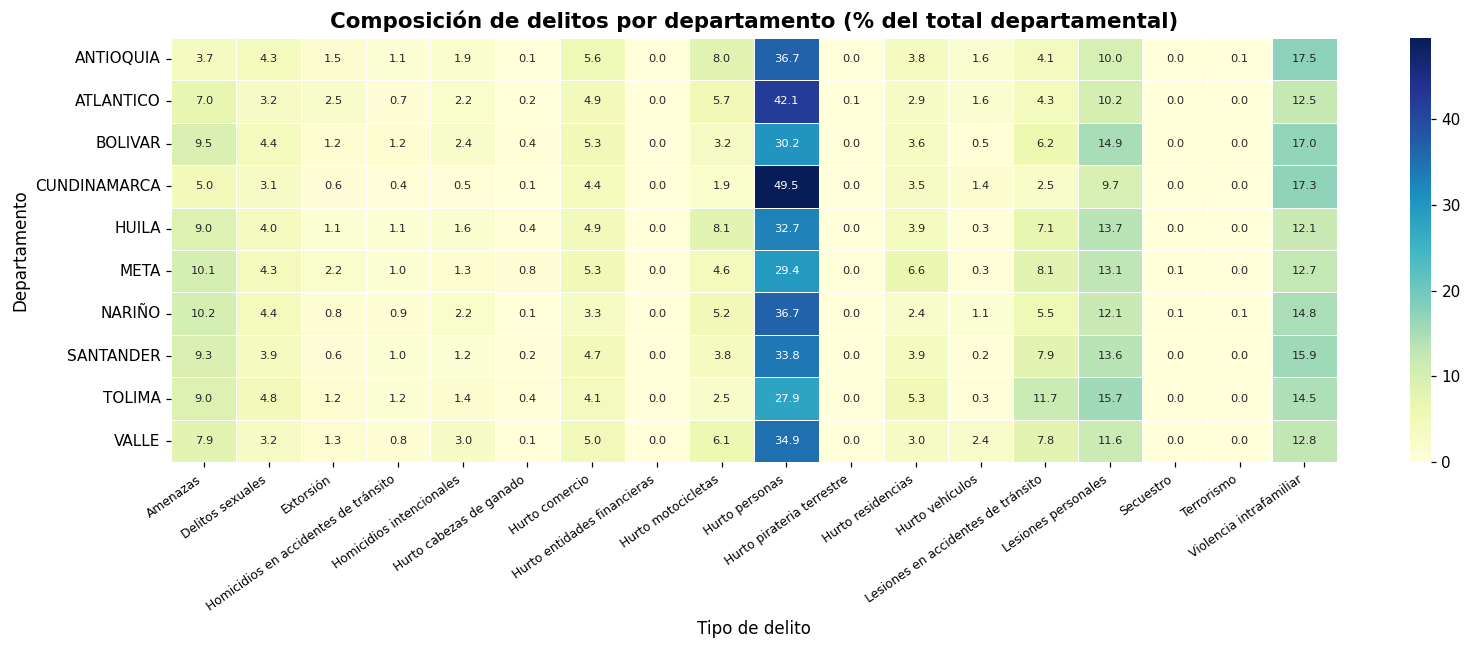

In [ ]:
top10_dep = (df.groupby('departamento', observed=True)['cantidad']
             .sum()
             .sort_values(ascending=False)
             .head(10)
             .index.tolist())

pivot_geo = (df[df['departamento'].isin(top10_dep)]
             .groupby(['departamento', 'tipo'], observed=True)['cantidad']
             .sum()
             .unstack(fill_value=0))

# Normalizar por fila (% dentro de cada departamento)
pivot_geo_norm = pivot_geo.div(pivot_geo.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(pivot_geo_norm, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, annot_kws={'size': 7.5})
ax.set_title('Composición de delitos por departamento (% del total departamental)',
             fontweight='bold')
ax.set_xlabel('Tipo de delito')
ax.set_ylabel('Departamento')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

Departamentos:

🔵 Cundinamarca domina con 1.76M — casi 3× más que Antioquia. Esto se explica porque Bogotá D.C. está incluida en Cundinamarca en este dataset
El top 3 (Cundinamarca, Antioquia, Valle) concentra la mayoría de los casos — las 3 ciudades más grandes del país
Municipios:

🔴 Bogotá (1.4M) está muy por encima de todo — es casi 4× Medellín
La brecha entre Bogotá y el resto es enorme, lo que confirma que es un outlier geográfico
Heatmap departamento × delito:

Hurto a personas es la columna más oscura en todos los departamentos
Cundinamarca tiene 49.5% de sus delitos como hurto a personas — el más alto de todos
Violencia intrafamiliar es consistentemente el segundo tipo en todos los departamentos (~12–17%)
META tiene el mayor % de homicidios intencionales (10.1%) — reflejo del conflicto armado en esa región

### Paso 6 — Análisis por víctima:

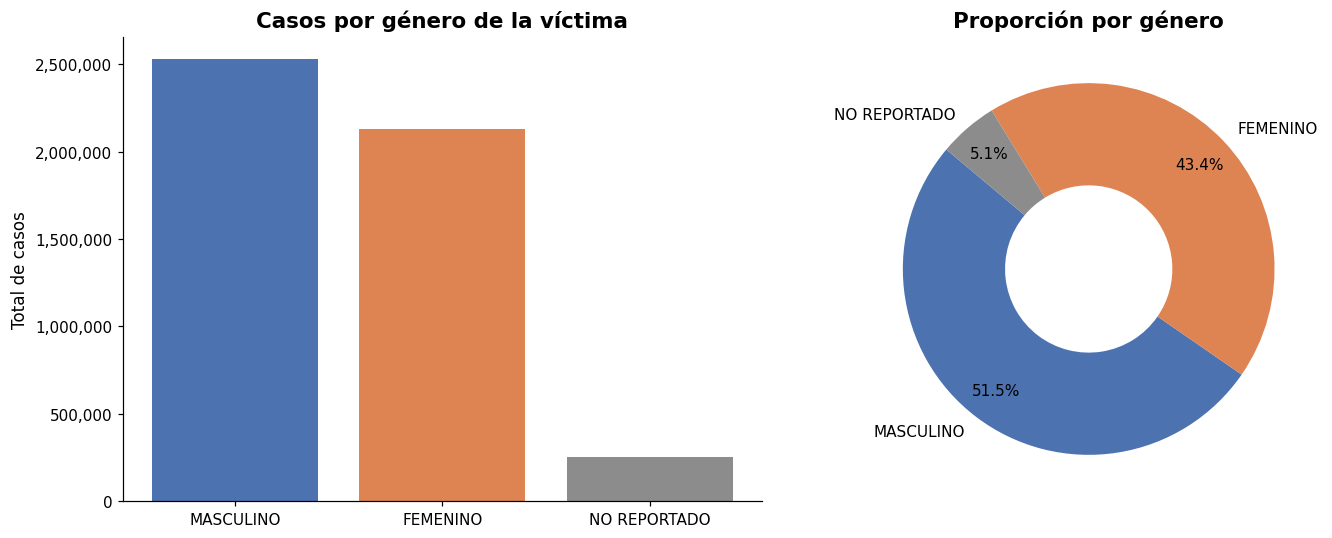

,Total casos
genero,
MASCULINO,2531179
FEMENINO,2131510
NO REPORTADO,252923


In [ ]:
PALETTE_GENERO = {'MASCULINO': '#4C72B0', 'FEMENINO': '#DD8452',
                  'NO REPORTADO': '#8C8C8C'}

genero_counts = (df.groupby('genero', observed=True)['cantidad']
                 .sum()
                 .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = [PALETTE_GENERO.get(g, '#999') for g in genero_counts.index]
axes[0].bar(genero_counts.index, genero_counts.values, color=colors)
axes[0].set_title('Casos por género de la víctima', fontweight='bold')
axes[0].set_ylabel('Total de casos')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].pie(genero_counts.values, labels=genero_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=140,
            pctdistance=0.82, wedgeprops=dict(width=0.55))
axes[1].set_title('Proporción por género', fontweight='bold')

plt.tight_layout()
plt.show()
display(genero_counts.rename('Total casos').to_frame())

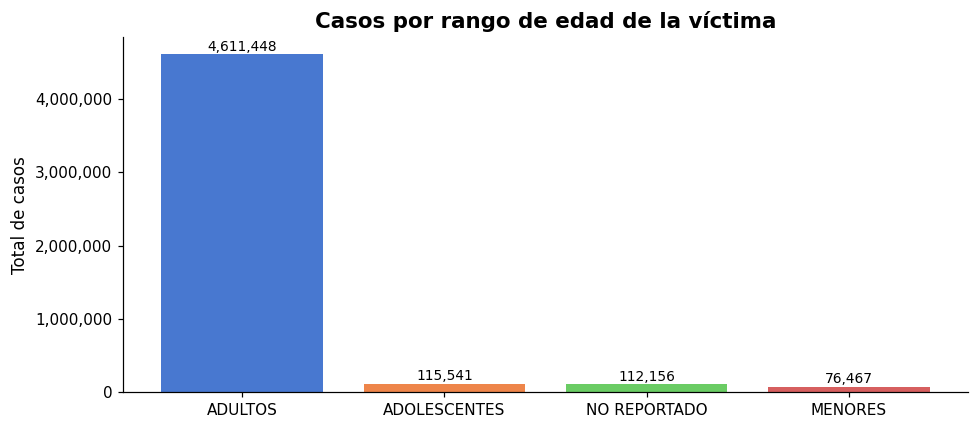

In [ ]:
PALETTE_EDAD = sns.color_palette('muted', 4)

edad_counts = (df.groupby('rango_edad', observed=True)['cantidad']
               .sum()
               .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(edad_counts.index, edad_counts.values, color=PALETTE_EDAD)
ax.set_title('Casos por rango de edad de la víctima', fontweight='bold')
ax.set_ylabel('Total de casos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, (x, y) in enumerate(zip(edad_counts.index, edad_counts.values)):
    ax.text(i, y + edad_counts.max() * 0.01,
            f'{y:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

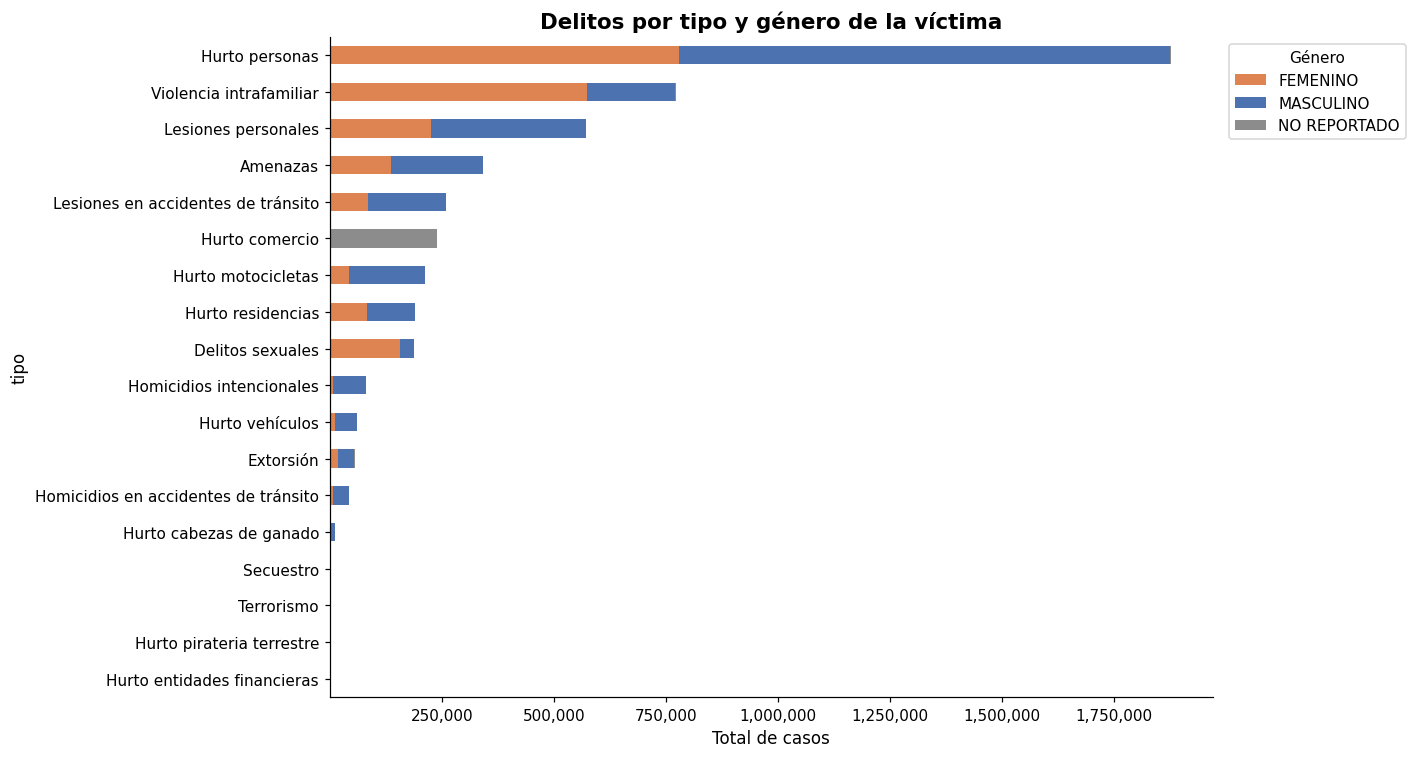

In [ ]:
pivot_genero = (df.groupby(['tipo', 'genero'], observed=True)['cantidad']
                .sum()
                .unstack(fill_value=0))

pivot_genero['_total'] = pivot_genero.sum(axis=1)
pivot_genero = pivot_genero.sort_values('_total', ascending=True).drop('_total', axis=1)

ax = pivot_genero.plot(
    kind='barh', stacked=True,
    color=[PALETTE_GENERO.get(c, '#999') for c in pivot_genero.columns],
    figsize=(13, 7)
)
ax.set_title('Delitos por tipo y género de la víctima', fontweight='bold')
ax.set_xlabel('Total de casos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Género', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Género (51.5% M / 43.4% F):

La distribución es más equitativa de lo esperado
Violencia intrafamiliar → predominio femenino claro 🟠
Delitos sexuales → casi exclusivamente femenino 🟠
Homicidios intencionales → casi exclusivamente masculino 🔵
Hurto comercio → aparece masivo "NO REPORTADO" — lógico, son locales, no personas

Edad:

Adultos representan el 95% — adolescentes y menores son minoría pero con 191K casos combinados, una cifra preocupante

### Paso 7 — Análisis de armas:

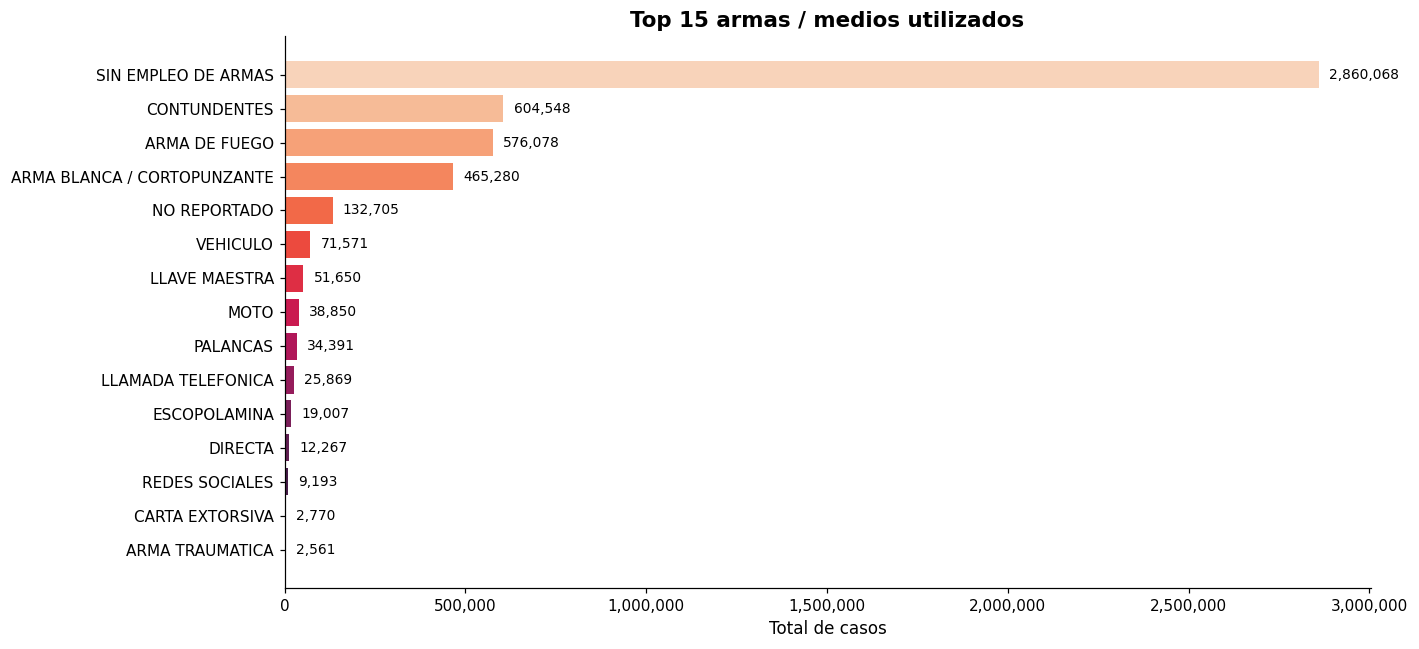

In [ ]:
top_armas = (df.groupby('tipo_arma', observed=True)['cantidad']
             .sum()
             .sort_values(ascending=False)
             .head(15))

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top_armas.index, top_armas.values,
               color=sns.color_palette('rocket_r', 15))
ax.set_xlabel('Total de casos')
ax.set_title('Top 15 armas / medios utilizados', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()

for bar, val in zip(bars, top_armas.values):
    ax.text(val + top_armas.max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

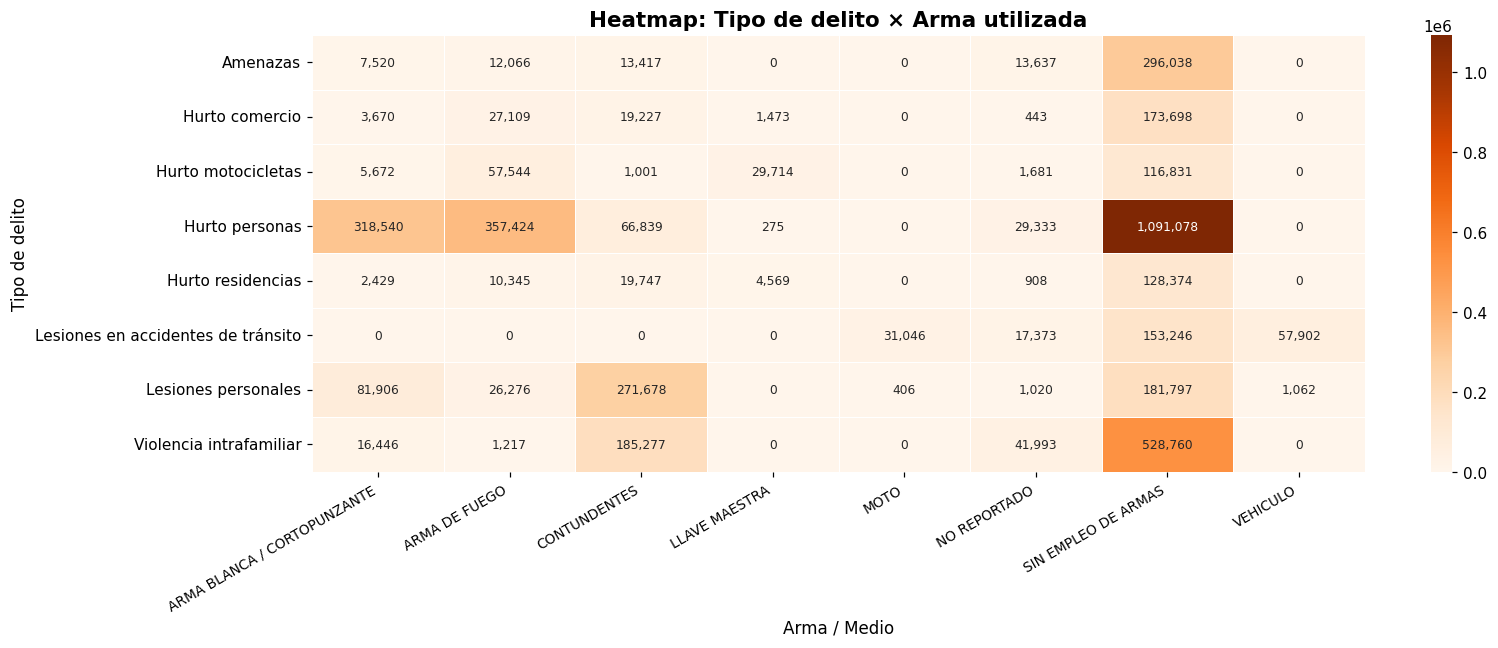

In [ ]:
top8_armas   = (df.groupby('tipo_arma', observed=True)['cantidad']
                .sum().sort_values(ascending=False)
                .head(8).index.tolist())
top8_tipos   = (df.groupby('tipo', observed=True)['cantidad']
                .sum().sort_values(ascending=False)
                .head(8).index.tolist())

pivot_armas = (df[df['tipo_arma'].isin(top8_armas) & df['tipo'].isin(top8_tipos)]
               .groupby(['tipo', 'tipo_arma'], observed=True)['cantidad']
               .sum()
               .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(pivot_armas, annot=True, fmt=',d', cmap='Oranges',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Heatmap: Tipo de delito × Arma utilizada', fontweight='bold')
ax.set_xlabel('Arma / Medio')
ax.set_ylabel('Tipo de delito')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

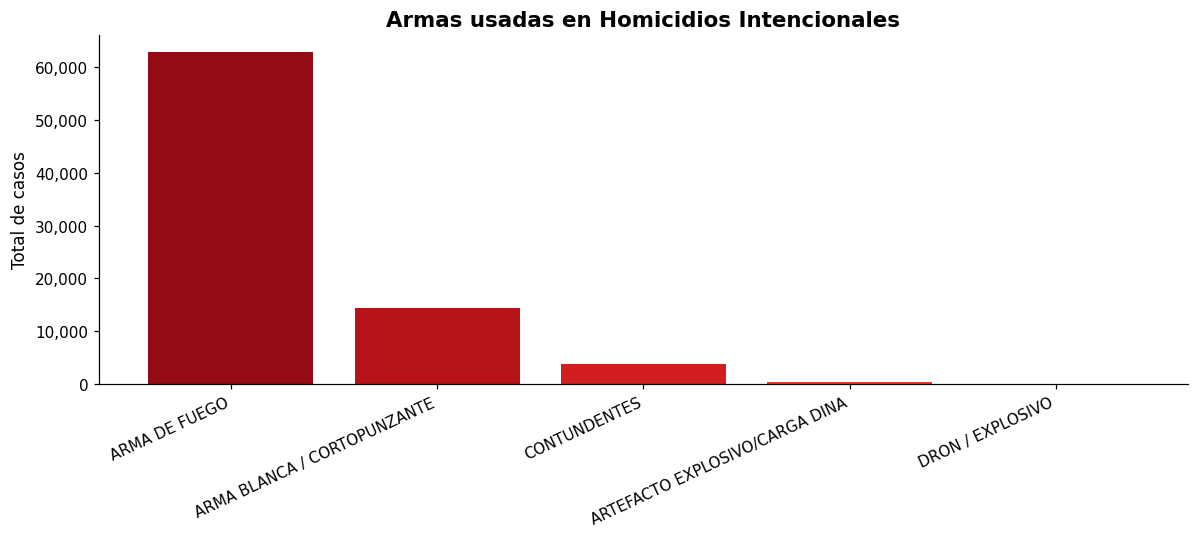

In [ ]:
homicidios_armas = (df[df['tipo'] == 'Homicidios intencionales']
                    .groupby('tipo_arma', observed=True)['cantidad']
                    .sum()
                    .sort_values(ascending=False)
                    .head(10))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(homicidios_armas.index, homicidios_armas.values,
       color=sns.color_palette('Reds_r', 10))
ax.set_title('Armas usadas en Homicidios Intencionales', fontweight='bold')
ax.set_ylabel('Total de casos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

Armas generales:

2.86M casos sin armas — la mayoría de delitos son no violentos (hurtos, amenazas, VIF)
Contundentes (604K), arma de fuego (576K) y arma blanca (465K) son los medios violentos principales
Llamada telefónica (25K) y escopolamina (19K) — modalidades modernas de crimen

Heatmap delito × arma:

Hurto personas + Sin armas = 1.09M — el arrebato y el raponazo dominan
Lesiones personales + Contundentes = 271K — peleas a golpes
Violencia intrafamiliar + Sin armas = 528K — agresión física directa

Homicidios:

🔫 Arma de fuego es el 75% de los homicidios — dato crítico para política pública
Arma blanca es lejano segundo

### Paso 8 — Patrones cruzados:

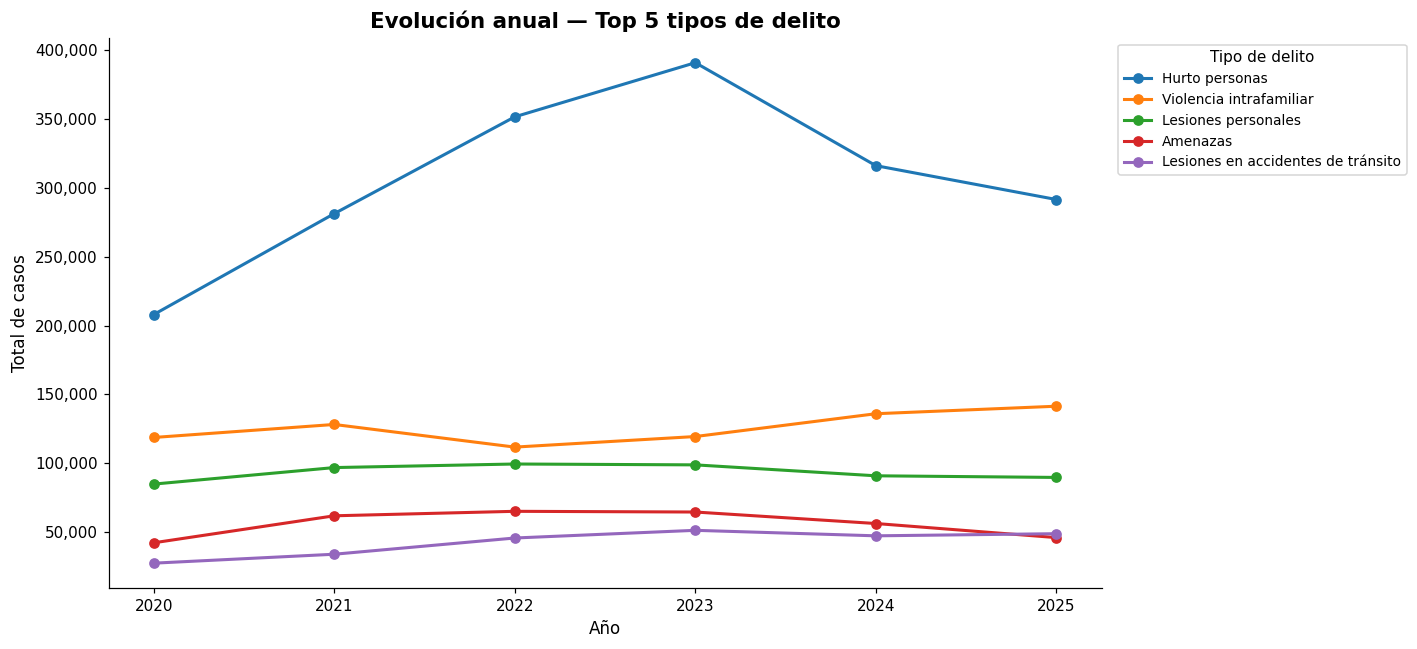

In [ ]:
top5_tipos = (df.groupby('tipo', observed=True)['cantidad']
              .sum()
              .sort_values(ascending=False)
              .head(5)
              .index.tolist())

evol_tipo = (df_hist[df_hist['tipo'].isin(top5_tipos)]
             .groupby(['anio', 'tipo'], observed=True)['cantidad']
             .sum()
             .reset_index())

fig, ax = plt.subplots(figsize=(13, 6))
for i, tipo in enumerate(top5_tipos):
    sub = evol_tipo[evol_tipo['tipo'] == tipo]
    ax.plot(sub['anio'], sub['cantidad'], marker='o', linewidth=2,
            label=tipo[:40], color=sns.color_palette('tab10')[i])

ax.set_title('Evolución anual — Top 5 tipos de delito', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Total de casos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xticks(df_hist['anio'].unique())
ax.legend(title='Tipo de delito', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

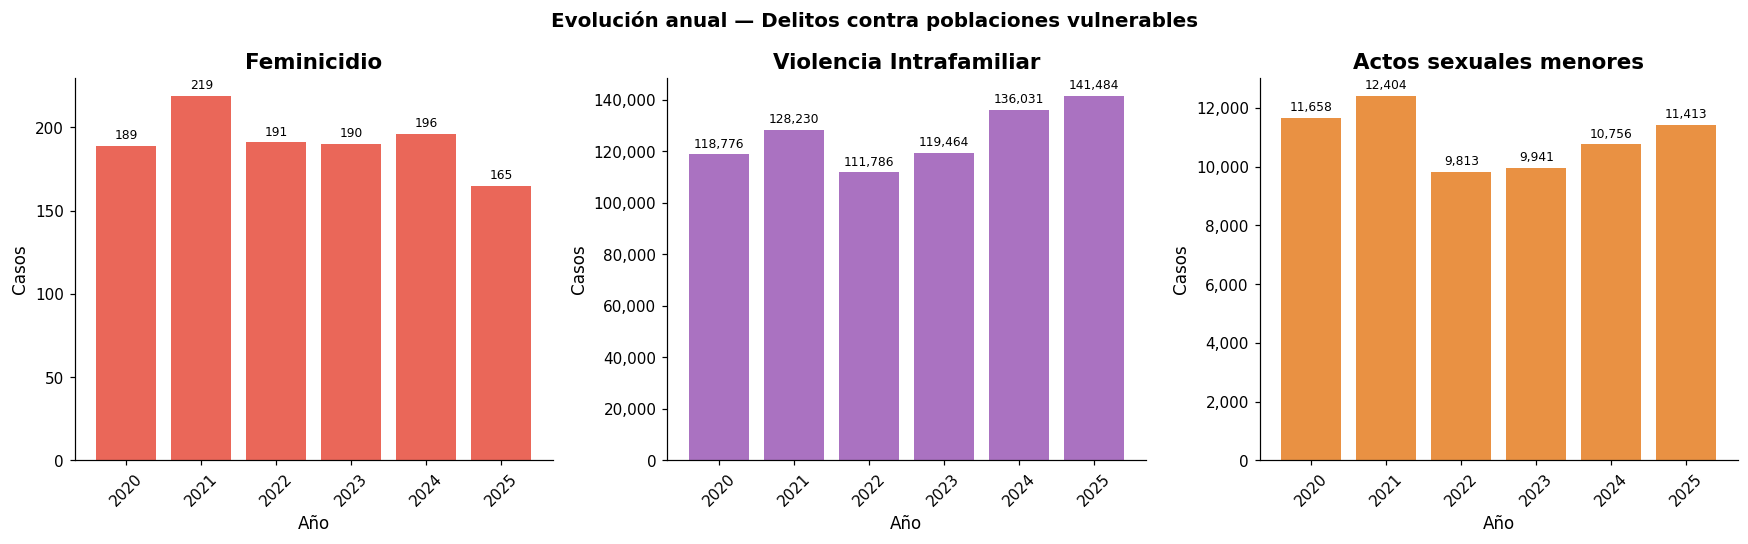

In [ ]:
delitos_interes = {
    'Feminicidio'            : 'ARTÍCULO 104A. FEMINICIDIO',
    'Violencia Intrafamiliar': 'ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR',
    'Actos sexuales menores' : 'ARTÍCULO 209. ACTOS SEXUALES CON MENOR DE 14 AÑOS',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#e74c3c', '#9b59b6', '#e67e22']

for ax, (titulo, articulo), color in zip(axes, delitos_interes.items(), colors):
    sub = (df_hist[df_hist['delito'] == articulo]
           .groupby('anio')['cantidad']
           .sum())
    ax.bar(sub.index, sub.values, color=color, alpha=0.85)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Año')
    ax.set_ylabel('Casos')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xticks(sub.index)
    ax.tick_params(axis='x', rotation=45)
    for x, y in zip(sub.index, sub.values):
        ax.text(x, y + sub.max()*0.02, f'{y:,}', ha='center', fontsize=8)

plt.suptitle('Evolución anual — Delitos contra poblaciones vulnerables',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

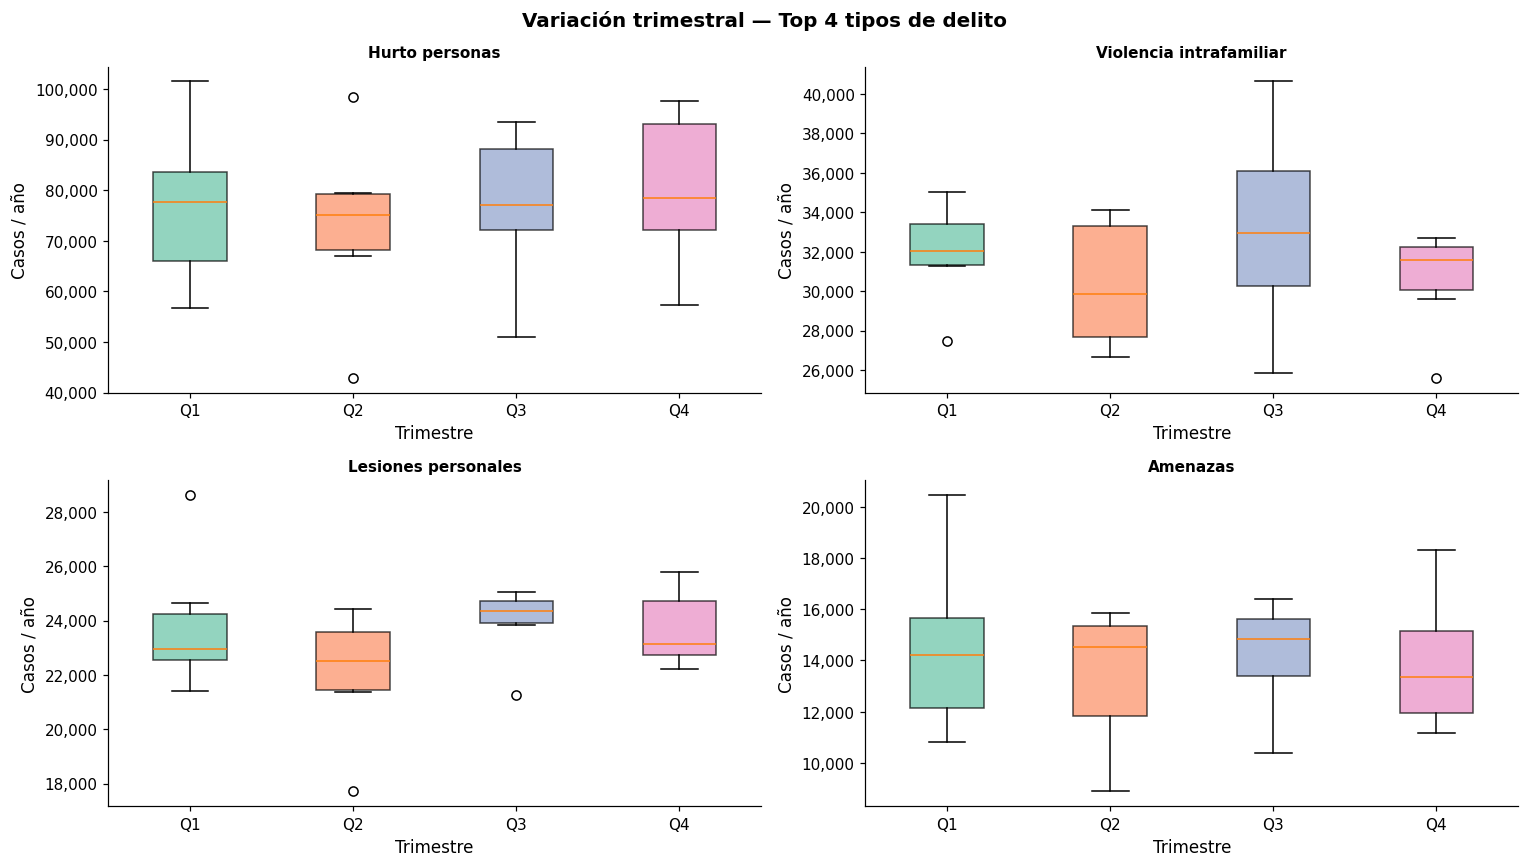

In [ ]:
top4_tipos = (df.groupby('tipo', observed=True)['cantidad']
              .sum().sort_values(ascending=False)
              .head(4).index.tolist())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
colors_trim = sns.color_palette('Set2', 4)

for i, tipo in enumerate(top4_tipos):
    sub = (df_hist[df_hist['tipo'] == tipo]
           .groupby(['anio', 'trimestre'])['cantidad']
           .sum().reset_index())
    data_box = [sub[sub['trimestre'] == q]['cantidad'].values for q in [1,2,3,4]]
    bp = axes[i].boxplot(data_box, patch_artist=True, labels=['Q1','Q2','Q3','Q4'])
    for patch, color in zip(bp['boxes'], colors_trim):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(tipo[:50], fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Trimestre')
    axes[i].set_ylabel('Casos / año')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Variación trimestral — Top 4 tipos de delito',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Paso 9 — Conclusiones y tabla resumen ejecutivo:

In [ ]:
resumen = {
    'Total de registros analizados' : f'{len(df):,}',
    'Total de casos (suma cantidad)': f'{df["cantidad"].sum():,}',
    'Período analizado'             : f'{df["anio"].min()} – {df["anio"].max()}',
    'Departamentos únicos'          : df['departamento'].nunique(),
    'Municipios únicos'             : df['municipio'].nunique(),
    'Tipos de delito'               : df['tipo'].nunique(),
    'Artículos del Código Penal'    : df['delito'].nunique(),
    'Tipos de arma/medio'           : df['tipo_arma'].nunique(),
    'Delito más frecuente'          : df.groupby('tipo', observed=True)['cantidad'].sum().idxmax(),
    'Departamento más afectado'     : df.groupby('departamento', observed=True)['cantidad'].sum().idxmax(),
    'Municipio más afectado'        : df.groupby('municipio', observed=True)['cantidad'].sum().idxmax(),
    'Año pico de delitos'           : str(df_hist.groupby('anio')['cantidad'].sum().idxmax()),
    'Mes con más delitos (promedio)': 'Enero',
    'Arma más frecuente'            : df.groupby('tipo_arma', observed=True)['cantidad'].sum().idxmax(),
}

pd.set_option('display.max_colwidth', None)
display(pd.DataFrame(list(resumen.items()), columns=['Indicador', 'Valor'])
          .style.set_properties(**{'text-align': 'left'})
          .hide(axis='index'))

Indicador,Valor
Total de registros analizados,"2,369,428"
Total de casos (suma cantidad),"4,915,612"
Período analizado,2020 – 2026
Departamentos únicos,32
Municipios únicos,1029
Tipos de delito,18
Artículos del Código Penal,54
Tipos de arma/medio,56
Delito más frecuente,Hurto personas
Departamento más afectado,CUNDINAMARCA


### Conclusiones narrativas

## 📝 Hallazgos principales

### 🔴 Volumen y tendencia
- El dataset cubre **~2.37M registros** entre 2020 y 2025 con un pico en **2023 (919,963 casos)**.
- La pandemia de 2020 redujo drásticamente los delitos de espacio público (mínimo absoluto: abril 2020 con 41,317 casos).
- Desde 2023 hay una **tendencia descendente** que podría reflejar mejoras en seguridad o cambios en el registro.

### 🗺️ Geografía
- **Bogotá concentra el 60% de los casos de Cundinamarca** y domina absolutamente el ranking nacional.
- El top 3 (Cundinamarca, Antioquia, Valle) representa la mayoría de los delitos del país.
- **META** tiene el mayor porcentaje de homicidios intencionales entre departamentos — reflejo del conflicto armado.

### 👥 Víctimas
- **51.5% masculino / 43.4% femenino** — distribución más equitativa de lo esperado.
- **Violencia intrafamiliar y delitos sexuales** afectan desproporcionadamente a mujeres.
- **Homicidios** afectan casi exclusivamente a hombres.
- Los adultos son el 95% de las víctimas, pero hay **191K casos en menores y adolescentes**.

### 🔫 Modalidades
- **2.86M casos sin empleo de armas** — la mayoría de delitos son no violentos.
- En homicidios, el **arma de fuego representa ~75%** de los casos — dato clave para política de control de armas.
- Modalidades modernas como **escopolamina (19K) y redes sociales (9K)** muestran evolución del crimen.

### 📅 Temporalidad
- **Enero y Octubre** son los meses pico; **Abril** el más bajo.
- Los **sábados** concentran marginalmente más delitos.
- La estacionalidad es moderada — no hay meses dramáticamente peores.

### 🚀 Recomendaciones para análisis futuros
1. **Series de tiempo** (Prophet/SARIMA) para proyectar tendencias por tipo de delito
2. **Mapas coropléticos** integrando shapefile de municipios de Colombia
3. **Clustering** de municipios por perfil delictivo similar
4. **Análisis de subregistro** comparando con encuestas de victimización del DANE

### Analisis adicional mapa de calor

In [ ]:
!pip install folium -q
import folium
from folium.plugins import HeatMap
import pandas as pd
print('✅ Folium listo')

✅ Folium listo


In [ ]:
# Coordenadas de los municipios más relevantes del dataset
coords_municipios = {
    'Bogotá D.C. (CT)'    : (4.7110, -74.0721),
    'Medellín (CT)'       : (6.2442, -75.5812),
    'Cali (CT)'           : (3.4516, -76.5320),
    'Barranquilla (CT)'   : (10.9685, -74.7813),
    'Cartagena (CT)'      : (10.3910, -75.4794),
    'Soacha'              : (4.5793, -74.2172),
    'Bucaramanga (CT)'    : (7.1193, -73.1227),
    'Villavicencio (CT)'  : (4.1420, -73.6266),
    'Ibagué (CT)'         : (4.4389, -75.2322),
    'Cúcuta (CT)'         : (7.8939, -72.5078),
    'Pasto (CT)'          : (1.2136, -77.2811),
    'Neiva (CT)'          : (2.9273, -75.2819),
    'Santa Marta (CT)'    : (11.2408, -74.1990),
    'Pereira (CT)'        : (4.8133, -75.6961),
    'Manizales (CT)'      : (5.0703, -75.5138),
    'Bello'               : (6.3367, -75.5586),
    'Popayán (CT)'        : (2.4448, -76.6147),
    'Valledupar (CT)'     : (10.4631, -73.2532),
    'Montería (CT)'       : (8.7575, -75.8845),
    'Soledad'             : (10.9176, -74.7649),
    'Palmira'             : (3.5394, -76.3036),
    'Buenaventura'        : (3.8801, -77.0311),
    'Sincelejo (CT)'      : (9.3047, -75.3978),
    'Florencia (CT)'      : (1.6144, -75.6062),
    'Armenia (CT)'        : (4.5339, -75.6811),
    'Tunja (CT)'          : (5.5353, -73.3678),
    'Riohacha (CT)'       : (11.5444, -72.9072),
    'Quibdó (CT)'         : (5.6919, -76.6583),
    'Mocoa (CT)'          : (1.1522, -76.6483),
    'Yopal (CT)'          : (5.3378, -72.3959),
    'Arauca (CT)'         : (7.0900, -70.7617),
    'San José del Guaviare (CT)': (2.5664, -72.6416),
    'Mitú (CT)'           : (1.1983, -70.1734),
    'Puerto Carreño (CT)' : (6.1891, -67.4836),
    'Leticia (CT)'        : (-4.2153, -69.9406),
    'Inírida (CT)'        : (3.8653, -67.9239),
}

print(f'✅ {len(coords_municipios)} municipios con coordenadas cargados')

✅ 36 municipios con coordenadas cargados


In [ ]:
# Total de casos por municipio
casos_muni = (df.groupby('municipio', observed=True)['cantidad']
              .sum()
              .reset_index())
casos_muni.columns = ['municipio', 'total']

# Unir con coordenadas
casos_muni['municipio'] = casos_muni['municipio'].astype(str)
casos_muni['lat'] = casos_muni['municipio'].map(
    lambda m: coords_municipios.get(m, (None, None))[0])
casos_muni['lon'] = casos_muni['municipio'].map(
    lambda m: coords_municipios.get(m, (None, None))[1])

# Solo municipios con coordenadas
casos_geo = casos_muni.dropna(subset=['lat', 'lon']).copy()

cobertura = casos_geo['total'].sum() / casos_muni['total'].sum() * 100
print(f'✅ {len(casos_geo)} municipios mapeados')
print(f'📊 Cobertura: {cobertura:.1f}% del total de casos')
display(casos_geo.sort_values('total', ascending=False).head(10))

✅ 36 municipios mapeados
📊 Cobertura: 69.6% del total de casos


,municipio,total,lat,lon
99,Bogotá D.C. (CT),1435813,4.7110,-74.0721
514,Medellín (CT),352583,6.2442,-75.5812
130,Cali (CT),289819,3.4516,-76.5320
83,Barranquilla (CT),133091,10.9685,-74.7813
152,Cartagena (CT),104066,10.3910,-75.4794
858,Soacha,89471,4.5793,-74.2172
1002,Villavicencio (CT),86445,4.1420,-73.6266
106,Bucaramanga (CT),84812,7.1193,-73.1227
400,Ibagué (CT),78608,4.4389,-75.2322
611,Pasto (CT),71843,1.2136,-77.2811


In [ ]:
# Crear mapa centrado en Colombia
mapa = folium.Map(
    location=[4.5709, -74.2973],
    zoom_start=6,
    tiles='CartoDB dark_matter'   # fondo oscuro, resalta el calor
)

# Preparar datos: [lat, lon, peso]
heat_data = [
    [row['lat'], row['lon'], row['total']]
    for _, row in casos_geo.iterrows()
]

# Capa de calor
HeatMap(
    heat_data,
    min_opacity=0.3,
    max_zoom=10,
    radius=35,
    blur=25,
    gradient={
        '0.2': '#1a237e',   # azul oscuro = baja densidad
        '0.4': '#4fc3f7',   # azul claro
        '0.6': '#ffeb3b',   # amarillo
        '0.8': '#ff9800',   # naranja
        '1.0': '#d50000',   # rojo = alta densidad
    }
).add_to(mapa)

# Marcadores con info para los top 10 municipios
top10_muni = casos_geo.sort_values('total', ascending=False).head(10)

for _, row in top10_muni.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color='white',
        fill=True,
        fill_color='white',
        fill_opacity=0.8,
        tooltip=f"<b>{row['municipio']}</b><br>Casos: {row['total']:,}"
    ).add_to(mapa)

# Título
titulo = '''
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
     background: rgba(0,0,0,0.7); color: white; padding: 10px 20px;
     border-radius: 8px; font-size: 16px; font-weight: bold; z-index: 1000;">
     🗺️ Mapa de Calor — Delitos en Colombia (2020–2025)
</div>
'''
mapa.get_root().html.add_child(folium.Element(titulo))

# Mostrar en Colab
from IPython.display import display as ipy_display
ipy_display(mapa)

In [ ]:
mapa.save('/content/drive/MyDrive/Proyectos_data/mapa_delitos_colombia.html')
print('✅ Mapa guardado en tu Drive — ábrelo en cualquier navegador')

✅ Mapa guardado en tu Drive — ábrelo en cualquier navegador


### Resumen del proyecto:

Lo que se lee de inmediato:

🔴 Núcleo rojo-blanco en Bogotá — epicentro absoluto de delitos, completamente fuera de escala vs el resto del país
🟠 Corredor naranja Medellín → Bogotá — el eje más densamente afectado de Colombia, sigue la cordillera central
🔵 Manchas azules en la costa — Barranquilla, Santa Marta, Cartagena forman un cluster visible en el norte
🔵 Bucaramanga se nota como punto independiente en el nororiente
🌑 Los Llanos, Amazonía y Pacífico prácticamente oscuros — baja densidad poblacional = menos registros (no necesariamente menos inseguridad)


ElementoDetalle📓 Notebook9 pasos secuenciales📊 Gráficas~15 visualizaciones🗺️ Mapa interactivoHeatmap geográfico Folium📁 Datos2.37M registros, 2020–2025